In [88]:
%load_ext autoreload

In [89]:
%autoreload 2
%aimport sog1_helpers

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import warnings

# Ignore all warnings
warnings.filterwarnings('ignore')

#plt.rcParams['text.usetex'] = True

plt.rcParams['ps.fonttype'] = 42
plt.rcParams["font.family"] = "Helvetica" #somethings this one doesnt work
plt.rcParams['pdf.fonttype'] = 42

In [90]:
activity_col = "Activity_S3_1"

# 1. Adding helicity to sog1 features table

In [91]:
sog1_features = pd.read_csv("../data/Sog1_AA_features.csv")
sog1_features

,Unnamed: 0,pos,aa,part,PS_lib1,PS_lib2,charge_lib1,charge_lib2,hydrophob_lib1,hydrophob_lib2
0,0,1,M,NTD,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2,A,NTD,NaN,NaN,NaN,NaN,NaN,NaN
2,2,3,G,NTD,NaN,NaN,NaN,NaN,NaN,NaN
3,3,4,R,NTD,NaN,NaN,NaN,positive,NaN,NaN
4,4,5,S,NTD,potential,potential,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
444,444,445,T,CTD,potential,potential,NaN,NaN,NaN,NaN
445,445,446,G,CTD,NaN,NaN,NaN,NaN,NaN,NaN
446,446,447,K,CTD,NaN,NaN,NaN,positive,NaN,NaN
447,447,448,T,CTD,potential,potential,NaN,NaN,NaN,NaN


From Margot's Slack message on 2/12/25:
- Helix 1: S356A-L370
- Helix 2: I391-L397
- Helix 3: P399-C409

Labeling based on Margot's Slack message on 2/17/25:
I noticed in the category with helix variants (Tab K. in excel file Visit2_V8_summary) that ...
Helix 1 ending is G371 instead of aforementioned L370, thus still not including phsophosite S372.
Helix 3 ending is K411 instead of aforementioned C409.

In [13]:
sog1_features["helix"] = ((356 <= sog1_features["pos"]) & (sog1_features["pos"] <= 371)) | ((391 <= sog1_features["pos"]) & (sog1_features["pos"] <= 397)) | ((399 <= sog1_features["pos"]) & (sog1_features["pos"] <= 411))
sog1_features

,Unnamed: 0,pos,aa,part,PS_lib1,PS_lib2,charge_lib1,charge_lib2,hydrophob_lib1,hydrophob_lib2,helix
0,0,1,M,NTD,NaN,NaN,NaN,NaN,NaN,NaN,False
1,1,2,A,NTD,NaN,NaN,NaN,NaN,NaN,NaN,False
2,2,3,G,NTD,NaN,NaN,NaN,NaN,NaN,NaN,False
3,3,4,R,NTD,NaN,NaN,NaN,positive,NaN,NaN,False
4,4,5,S,NTD,potential,potential,NaN,NaN,NaN,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...
444,444,445,T,CTD,potential,potential,NaN,NaN,NaN,NaN,False
445,445,446,G,CTD,NaN,NaN,NaN,NaN,NaN,NaN,False
446,446,447,K,CTD,NaN,NaN,NaN,positive,NaN,NaN,False
447,447,448,T,CTD,potential,potential,NaN,NaN,NaN,NaN,False


In [59]:
sog1_features["part"].value_counts()

part
CTD    238
NAC    154
NTD     57
Name: count, dtype: int64

In [35]:
sog1_features[sog1_features["helix"]]

,Unnamed: 0,pos,aa,part,PS_lib1,PS_lib2,charge_lib1,charge_lib2,hydrophob_lib1,hydrophob_lib2,helix
355,355,356,S,CTD,confirmed,confirmed,NaN,NaN,NaN,NaN,True
356,356,357,Q,CTD,NaN,NaN,NaN,neutral,NaN,NaN,True
357,357,358,Q,CTD,NaN,NaN,NaN,neutral,NaN,NaN,True
358,358,359,L,CTD,NaN,NaN,NaN,NaN,hydrofobic,hydrofobic,True
359,359,360,V,CTD,NaN,NaN,NaN,NaN,NaN,NaN,True
360,360,361,E,CTD,NaN,NaN,negative,negative,NaN,NaN,True
361,361,362,A,CTD,NaN,NaN,NaN,NaN,NaN,NaN,True
362,362,363,L,CTD,NaN,NaN,NaN,NaN,hydrofobic,hydrofobic,True
363,363,364,S,CTD,potential,potential,NaN,NaN,NaN,NaN,True
364,364,365,L,CTD,NaN,NaN,NaN,NaN,hydrofobic,hydrofobic,True


Text(0.5, 0, '')

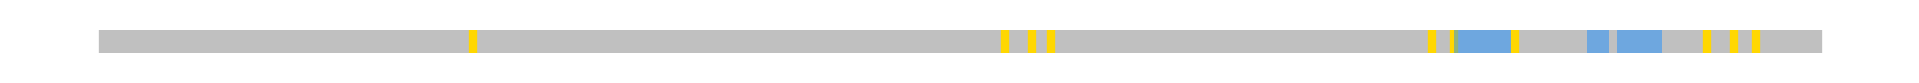

In [85]:
# Summary vis, need to oimprove


fig, ax = plt.subplots(figsize = (8,0.1), dpi = 300)

sns.lineplot(data = sog1_features, x = "pos", y = 1, ax = ax, lw = 8, zorder = 0, color = 'silver')
#sns.scatterplot(data = sog1_features[sog1_features["PS_lib2"] == "confirmed"], x = "pos", y = 1, ax = ax, color = 'orange', zorder = 10, s = 5, marker = 's')

for pos in sog1_features[sog1_features["PS_lib2"] == "confirmed"]["pos"]:
    ax.axvline(pos, lw = 2, color = 'gold', alpha = 1)

ax.axvspan(356, 371, facecolor='dodgerblue', zorder = 20, alpha = 0.5)
ax.axvspan(391, 397, facecolor='dodgerblue', zorder = 20, alpha = 0.5)
ax.axvspan(399, 411, facecolor='dodgerblue', zorder = 20, alpha = 0.5)

sns.despine(left = True, bottom = True)
ax.set_yticks([])
ax.set_xticks([])
ax.set_xlabel("")

# 2. Proline/glycine scans

In [121]:
def return_scan_tiles(AA):
    Ascan = sog1_helpers.return_activities(AA + "scan")
    Ascan_s = Ascan[~Ascan["Description"].str.contains("comb")]#["Other"].value_counts()
    Ascan_s["tile_num"] = Ascan_s["Description"].str.split("_").str[0].astype(int)
    Ascan_s["var_start"] = Ascan_s["Description"].str.split("_").str[-1].str.split("-").str[0].astype(int) + Ascan_s["Start"] - 1
    Ascan_s["var_end"] = Ascan_s["Description"].str.split("_").str[-1].str.split("-").str[1].astype(int) + Ascan_s["Start"] - 1
    Ascan_s["var_start"] = Ascan_s["var_start"].astype(int)
    Ascan_s["var_end"] = Ascan_s["var_end"].astype(int)
    display(Ascan_s)
    Ascan_s = Ascan_s.dropna(subset = activity_col)
    return Ascan_s

In [122]:
# No measurements for P scan
return_scan_tiles("P")

,Description,Other,Start,mid,End,tile,Activity_S3_1,Activity_S3_2,lib2_avg,tile_num,var_start,var_end
0,3_Pscan_1-4,NaN,21,41,61,PPPPDPRQVVWKSNPSRHCPKCQHVIDNSDAVDDWPGLPR,NaN,NaN,NaN,3,21,24
1,3_Pscan_5-8,NaN,21,41,61,SASSPPPPVVWKSNPSRHCPKCQHVIDNSDAVDDWPGLPR,NaN,NaN,NaN,3,25,28
2,3_Pscan_9-12,NaN,21,41,61,SASSDPRQPPPPSNPSRHCPKCQHVIDNSDAVDDWPGLPR,NaN,NaN,NaN,3,29,32
3,3_Pscan_13-16,NaN,21,41,61,SASSDPRQVVWKPPPPRHCPKCQHVIDNSDAVDDWPGLPR,NaN,NaN,NaN,3,33,36
4,3_Pscan_17-20,NaN,21,41,61,SASSDPRQVVWKSNPSPPPPKCQHVIDNSDAVDDWPGLPR,NaN,NaN,NaN,3,37,40
...,...,...,...,...,...,...,...,...,...,...,...,...
175,42_Pscan_21-24,NaN,410,430,450,QKIVLDPSNIELDTPPEFRLPPPPFGSQDSFLAWGTGKTD,NaN,NaN,NaN,42,430,433
176,42_Pscan_25-28,NaN,410,430,450,QKIVLDPSNIELDTPPEFRLSQLEPPPPDSFLAWGTGKTD,NaN,NaN,NaN,42,434,437
177,42_Pscan_29-32,NaN,410,430,450,QKIVLDPSNIELDTPPEFRLSQLEFGSQPPPPAWGTGKTD,NaN,NaN,NaN,42,438,441
178,42_Pscan_33-36,NaN,410,430,450,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSFLPPPPGKTD,NaN,NaN,NaN,42,442,445


,Description,Other,Start,mid,End,tile,Activity_S3_1,Activity_S3_2,lib2_avg,tile_num,var_start,var_end


In [123]:
# No measurements for G scan
return_scan_tiles("G")

,Description,Other,Start,mid,End,tile,Activity_S3_1,Activity_S3_2,lib2_avg,tile_num,var_start,var_end
0,3_Gscan_1-4,NaN,21,41,61,GGGGDPRQVVWKSNPSRHCPKCQHVIDNSDAVDDWPGLPR,NaN,NaN,NaN,3,21,24
1,3_Gscan_5-8,NaN,21,41,61,SASSGGGGVVWKSNPSRHCPKCQHVIDNSDAVDDWPGLPR,NaN,NaN,NaN,3,25,28
2,3_Gscan_9-12,NaN,21,41,61,SASSDPRQGGGGSNPSRHCPKCQHVIDNSDAVDDWPGLPR,NaN,NaN,NaN,3,29,32
3,3_Gscan_13-16,NaN,21,41,61,SASSDPRQVVWKGGGGRHCPKCQHVIDNSDAVDDWPGLPR,NaN,NaN,NaN,3,33,36
4,3_Gscan_17-20,NaN,21,41,61,SASSDPRQVVWKSNPSGGGGKCQHVIDNSDAVDDWPGLPR,NaN,NaN,NaN,3,37,40
...,...,...,...,...,...,...,...,...,...,...,...,...
175,42_Gscan_21-24,NaN,410,430,450,QKIVLDPSNIELDTPPEFRLGGGGFGSQDSFLAWGTGKTD,NaN,NaN,NaN,42,430,433
176,42_Gscan_25-28,NaN,410,430,450,QKIVLDPSNIELDTPPEFRLSQLEGGGGDSFLAWGTGKTD,NaN,NaN,NaN,42,434,437
177,42_Gscan_29-32,NaN,410,430,450,QKIVLDPSNIELDTPPEFRLSQLEFGSQGGGGAWGTGKTD,NaN,NaN,NaN,42,438,441
178,42_Gscan_33-36,NaN,410,430,450,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSFLGGGGGKTD,NaN,NaN,NaN,42,442,445


,Description,Other,Start,mid,End,tile,Activity_S3_1,Activity_S3_2,lib2_avg,tile_num,var_start,var_end


# Exploring helicity predictor

In [124]:
import metapredict as meta

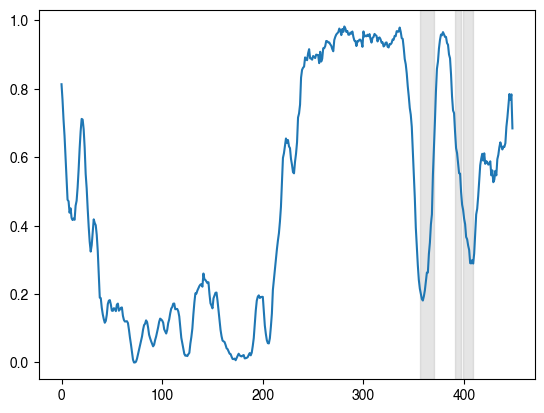

In [136]:
sns.lineplot(meta.predict_disorder("".join(sog1_features["aa"])))
plt.axvspan(356, 370, alpha = 0.2, color = 'gray')

plt.axvspan(391, 397, alpha = 0.2, color = 'gray')

plt.axvspan(399, 409, alpha = 0.2, color = 'gray')

In [139]:
meta.percent_disorder("GGGGG")

100.0

In [140]:
shuffle_vars = sog1_helpers.return_activities("_shuffle_size")
shuffle_vars["Description"].str.split("_").str[0].value_counts()
# WT tiles
BasicArTh = sog1_helpers.return_activities("BasicArTh", pos_regex = r'\.(\d+)')
shuffle_vars_with_diff = sog1_helpers.add_all_var_positions(shuffle_vars, BasicArTh, activity_col, add_AAs = True)
shuffle_vars_with_diff["tile"] = shuffle_vars_with_diff["Description_var"].str.split("_").str[0].astype(int)
shuffle_vars_with_diff["shuffle_size"] = shuffle_vars_with_diff["Other_var"].str.split("shuffle_size").str[1].str.split("_").str[0].astype(int)
shuffle_vars_with_diff["coordinates"] = shuffle_vars_with_diff["Description_var"].str.split("pos").str[-1]
shuffle_vars_with_diff["pos_start"] = shuffle_vars_with_diff["coordinates"].str.split("_").str[0].astype(int) 
shuffle_vars_with_diff["pos_start"] = shuffle_vars_with_diff["Start"] + 2 * shuffle_vars_with_diff["pos_start"]

shuffle_vars_with_diff["pos_end"] = shuffle_vars_with_diff["pos_start"] + shuffle_vars_with_diff["shuffle_size"]
shuffle_vars_with_diff

,Description_var,Other_var,Start,mid,End,tile_var,Activity_S3_1_var,Activity_S3_2_var,lib2_avg_var,Description_wt,...,Activity_S3_1_wt,Activity_S3_2_wt,lib2_avg_wt,vars,AAs,tile,shuffle_size,coordinates,pos_start,pos_end
0,33_shuffle_size2_ss2_pos0_1,shuffle_size2_ss2_pos0_1,321,341,361,MELDDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,551.074606,746.700944,648.887775,BasicArTh.33,...,940.578923,884.466877,912.522900,"[321, 322]","[E, M]",33,2,0_1,321,323
1,33_shuffle_size2_ss2_pos1_1,shuffle_size2_ss2_pos1_1,321,341,361,EMDLDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,853.514237,777.756933,815.635585,BasicArTh.33,...,940.578923,884.466877,912.522900,"[323, 324]","[L, D]",33,2,1_1,323,325
2,33_shuffle_size2_ss2_pos2_1,shuffle_size2_ss2_pos2_1,321,341,361,EMLDKDEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,1940.821638,NaN,1940.821638,BasicArTh.33,...,940.578923,884.466877,912.522900,"[325, 326]","[D, K]",33,2,2_1,325,327
3,33_shuffle_size2_ss2_pos4_1,shuffle_size2_ss2_pos4_1,321,341,361,EMLDDKEEEQKDRDNENQGEEDPTWFDSGSQFILNSQQLV,NaN,NaN,NaN,BasicArTh.33,...,940.578923,884.466877,912.522900,"[329, 330]","[Q, E]",33,2,4_1,329,331
4,33_shuffle_size2_ss2_pos5_1,shuffle_size2_ss2_pos5_1,321,341,361,EMLDDKEEQEDKRDNENQGEEDPTWFDSGSQFILNSQQLV,656.065410,619.839891,637.952651,BasicArTh.33,...,940.578923,884.466877,912.522900,"[331, 332]","[K, D]",33,2,5_1,331,333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3568,42_shuffle_size10_ss2_pos15_6,shuffle_size10_ss2_pos15_6,410,430,450,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSLWTGADFGTK,966.536960,805.704010,886.120485,BasicArTh.42,...,2221.196339,2039.845552,2130.520945,"[440, 441, 442, 443, 444, 445, 446, 447, 449]","[F, L, A, W, G, T, G, K, D]",42,10,15_6,440,450
3569,42_shuffle_size10_ss2_pos15_7,shuffle_size10_ss2_pos15_7,410,430,450,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSTTKGDALWFG,3552.934400,3813.512564,3683.223482,BasicArTh.42,...,2221.196339,2039.845552,2130.520945,"[440, 441, 442, 443, 444, 445, 446, 447, 448, ...","[F, L, A, W, G, T, G, K, T, D]",42,10,15_7,440,450
3570,42_shuffle_size10_ss2_pos15_8,shuffle_size10_ss2_pos15_8,410,430,450,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSTLDFGKGATW,NaN,NaN,NaN,BasicArTh.42,...,2221.196339,2039.845552,2130.520945,"[440, 442, 443, 445, 447, 449]","[F, A, W, T, K, D]",42,10,15_8,440,450
3571,42_shuffle_size10_ss2_pos15_9,shuffle_size10_ss2_pos15_9,410,430,450,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSTWFTGGADLK,1073.443438,NaN,1073.443438,BasicArTh.42,...,2221.196339,2039.845552,2130.520945,"[440, 441, 442, 443, 445, 446, 447, 448, 449]","[F, L, A, W, T, G, K, T, D]",42,10,15_9,440,450


In [141]:
shuffle_vars_with_diff["var_disorder"] = [meta.percent_disorder(_) for _ in shuffle_vars_with_diff["tile_var"]]
shuffle_vars_with_diff["wt_disorder"] = [meta.percent_disorder(_) for _ in shuffle_vars_with_diff["tile_wt"]]
shuffle_vars_with_diff

,Description_var,Other_var,Start,mid,End,tile_var,Activity_S3_1_var,Activity_S3_2_var,lib2_avg_var,Description_wt,...,lib2_avg_wt,vars,AAs,tile,shuffle_size,coordinates,pos_start,pos_end,var_disorder,wt_disorder
0,33_shuffle_size2_ss2_pos0_1,shuffle_size2_ss2_pos0_1,321,341,361,MELDDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,551.074606,746.700944,648.887775,BasicArTh.33,...,912.522900,"[321, 322]","[E, M]",33,2,0_1,321,323,97.5,97.5
1,33_shuffle_size2_ss2_pos1_1,shuffle_size2_ss2_pos1_1,321,341,361,EMDLDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,853.514237,777.756933,815.635585,BasicArTh.33,...,912.522900,"[323, 324]","[L, D]",33,2,1_1,323,325,97.5,97.5
2,33_shuffle_size2_ss2_pos2_1,shuffle_size2_ss2_pos2_1,321,341,361,EMLDKDEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,1940.821638,NaN,1940.821638,BasicArTh.33,...,912.522900,"[325, 326]","[D, K]",33,2,2_1,325,327,97.5,97.5
3,33_shuffle_size2_ss2_pos4_1,shuffle_size2_ss2_pos4_1,321,341,361,EMLDDKEEEQKDRDNENQGEEDPTWFDSGSQFILNSQQLV,NaN,NaN,NaN,BasicArTh.33,...,912.522900,"[329, 330]","[Q, E]",33,2,4_1,329,331,97.5,97.5
4,33_shuffle_size2_ss2_pos5_1,shuffle_size2_ss2_pos5_1,321,341,361,EMLDDKEEQEDKRDNENQGEEDPTWFDSGSQFILNSQQLV,656.065410,619.839891,637.952651,BasicArTh.33,...,912.522900,"[331, 332]","[K, D]",33,2,5_1,331,333,97.5,97.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3568,42_shuffle_size10_ss2_pos15_6,shuffle_size10_ss2_pos15_6,410,430,450,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSLWTGADFGTK,966.536960,805.704010,886.120485,BasicArTh.42,...,2130.520945,"[440, 441, 442, 443, 444, 445, 446, 447, 449]","[F, L, A, W, G, T, G, K, D]",42,10,15_6,440,450,100.0,100.0
3569,42_shuffle_size10_ss2_pos15_7,shuffle_size10_ss2_pos15_7,410,430,450,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSTTKGDALWFG,3552.934400,3813.512564,3683.223482,BasicArTh.42,...,2130.520945,"[440, 441, 442, 443, 444, 445, 446, 447, 448, ...","[F, L, A, W, G, T, G, K, T, D]",42,10,15_7,440,450,97.5,100.0
3570,42_shuffle_size10_ss2_pos15_8,shuffle_size10_ss2_pos15_8,410,430,450,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSTLDFGKGATW,NaN,NaN,NaN,BasicArTh.42,...,2130.520945,"[440, 442, 443, 445, 447, 449]","[F, A, W, T, K, D]",42,10,15_8,440,450,97.5,100.0
3571,42_shuffle_size10_ss2_pos15_9,shuffle_size10_ss2_pos15_9,410,430,450,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSTWFTGGADLK,1073.443438,NaN,1073.443438,BasicArTh.42,...,2130.520945,"[440, 441, 442, 443, 445, 446, 447, 448, 449]","[F, L, A, W, T, G, K, T, D]",42,10,15_9,440,450,90.0,100.0


<Axes: xlabel='wt_disorder', ylabel='var_disorder'>

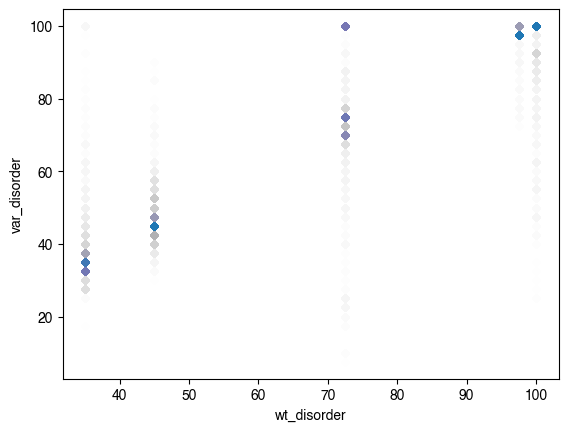

In [157]:
sns.scatterplot(data = shuffle_vars_with_diff, x = "wt_disorder", y = "var_disorder", alpha = 0.005)

In [160]:
shuffle_vars_with_diff["delta_disorder"] = shuffle_vars_with_diff["var_disorder"] - shuffle_vars_with_diff["wt_disorder"]
shuffle_vars_with_diff["delta_activity"] = shuffle_vars_with_diff["Activity_S3_1_var"] - shuffle_vars_with_diff["Activity_S3_1_wt"]
shuffle_vars_with_diff

,Description_var,Other_var,Start,mid,End,tile_var,Activity_S3_1_var,Activity_S3_2_var,lib2_avg_var,Description_wt,...,AAs,tile,shuffle_size,coordinates,pos_start,pos_end,var_disorder,wt_disorder,delta_disorder,delta_activity
0,33_shuffle_size2_ss2_pos0_1,shuffle_size2_ss2_pos0_1,321,341,361,MELDDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,551.074606,746.700944,648.887775,BasicArTh.33,...,"[E, M]",33,2,0_1,321,323,97.5,97.5,0.0,-389.504317
1,33_shuffle_size2_ss2_pos1_1,shuffle_size2_ss2_pos1_1,321,341,361,EMDLDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,853.514237,777.756933,815.635585,BasicArTh.33,...,"[L, D]",33,2,1_1,323,325,97.5,97.5,0.0,-87.064686
2,33_shuffle_size2_ss2_pos2_1,shuffle_size2_ss2_pos2_1,321,341,361,EMLDKDEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,1940.821638,NaN,1940.821638,BasicArTh.33,...,"[D, K]",33,2,2_1,325,327,97.5,97.5,0.0,1000.242715
3,33_shuffle_size2_ss2_pos4_1,shuffle_size2_ss2_pos4_1,321,341,361,EMLDDKEEEQKDRDNENQGEEDPTWFDSGSQFILNSQQLV,NaN,NaN,NaN,BasicArTh.33,...,"[Q, E]",33,2,4_1,329,331,97.5,97.5,0.0,NaN
4,33_shuffle_size2_ss2_pos5_1,shuffle_size2_ss2_pos5_1,321,341,361,EMLDDKEEQEDKRDNENQGEEDPTWFDSGSQFILNSQQLV,656.065410,619.839891,637.952651,BasicArTh.33,...,"[K, D]",33,2,5_1,331,333,97.5,97.5,0.0,-284.513513
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3568,42_shuffle_size10_ss2_pos15_6,shuffle_size10_ss2_pos15_6,410,430,450,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSLWTGADFGTK,966.536960,805.704010,886.120485,BasicArTh.42,...,"[F, L, A, W, G, T, G, K, D]",42,10,15_6,440,450,100.0,100.0,0.0,-1254.659380
3569,42_shuffle_size10_ss2_pos15_7,shuffle_size10_ss2_pos15_7,410,430,450,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSTTKGDALWFG,3552.934400,3813.512564,3683.223482,BasicArTh.42,...,"[F, L, A, W, G, T, G, K, T, D]",42,10,15_7,440,450,97.5,100.0,-2.5,1331.738061
3570,42_shuffle_size10_ss2_pos15_8,shuffle_size10_ss2_pos15_8,410,430,450,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSTLDFGKGATW,NaN,NaN,NaN,BasicArTh.42,...,"[F, A, W, T, K, D]",42,10,15_8,440,450,97.5,100.0,-2.5,NaN
3571,42_shuffle_size10_ss2_pos15_9,shuffle_size10_ss2_pos15_9,410,430,450,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSTWFTGGADLK,1073.443438,NaN,1073.443438,BasicArTh.42,...,"[F, L, A, W, T, G, K, T, D]",42,10,15_9,440,450,90.0,100.0,-10.0,-1147.752901


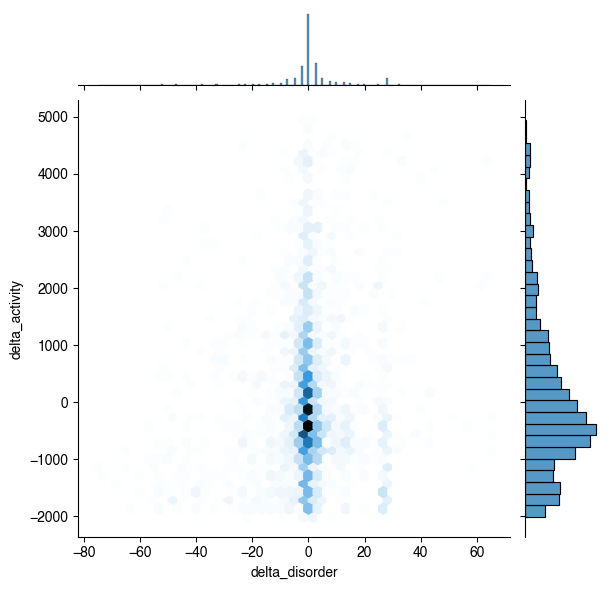

In [166]:
sns.jointplot(data = shuffle_vars_with_diff, x = "delta_disorder", y = "delta_activity", kind = 'hex')

<Axes: xlabel='delta_disorder', ylabel='delta_activity'>

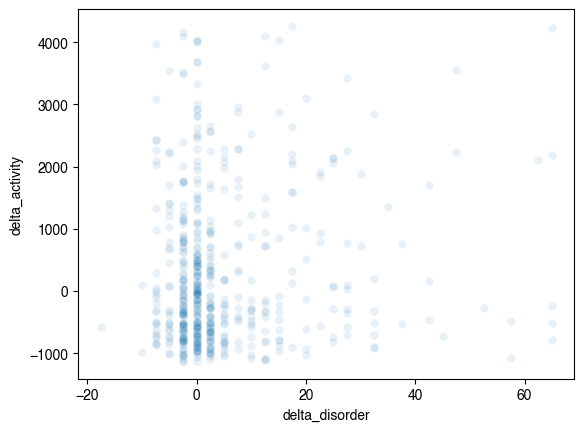

In [192]:
sns.scatterplot(data = shuffle_vars_with_diff[shuffle_vars_with_diff["tile"] == 35], x = "delta_disorder", y = "delta_activity", alpha = 0.1)

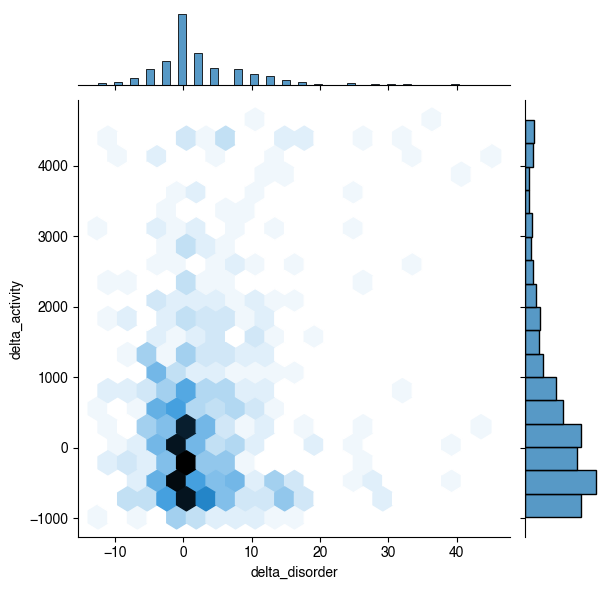

In [182]:
sns.jointplot(data = shuffle_vars_with_diff[shuffle_vars_with_diff["tile"] == 34], x = "delta_disorder", y = "delta_activity", kind = 'hex', gridsize = 20)